In [2]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import snntorch as snn
import snntorch.spikegen as spikegen


df = pd.read_csv("final_data.csv")



In [3]:
df['Flow_delta'] = df['Flow_L_min'].diff()

In [4]:
df['Flow_delta'] = df['Flow_delta'].fillna(0)

In [5]:
df['Flow_low'] = (df['Flow_L_min'] < 0.2).astype(int)

In [6]:
df['Flow_ratio'] = df['Flow_L_min'] / (df['Turbidity_smooth'] + 1)

In [7]:
df

,Flow_L_min,label,TDS_smooth,Turbidity_smooth,Flow_delta,Flow_low,Flow_ratio
0,0.27,2,825.6,2532.2,0.00,0,0.000107
1,0.53,1,1229.0,3100.2,0.26,0,0.000171
2,0.27,2,899.0,3121.0,-0.26,0,0.000086
3,0.27,2,816.6,2424.0,0.00,0,0.000111
4,1.33,0,934.2,1662.2,1.06,0,0.000800
...,...,...,...,...,...,...,...
3540,0.27,2,811.0,2393.0,0.14,0,0.000113
3541,0.27,2,979.0,2426.8,0.00,0,0.000111
3542,1.33,0,979.8,1738.6,1.06,0,0.000765
3543,0.27,2,1030.4,2704.0,-1.06,0,0.000100


In [ ]:

X = df[['TDS_smooth','Turbidity_smooth','Flow_L_min','Flow_delta','Flow_low',"Flow_ratio"]]
y = df['label']



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)


scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values)
y_test = torch.tensor(y_test.values)


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)



num_inputs = 6
num_hidden = 20
num_outputs = 4
num_steps = 40




class Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=0.9)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=0.9)

    def forward(self, x):

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []

        for step in range(x.size(0)):

            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)

        return torch.stack(spk2_rec)



model = Net()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)




epochs = 50

for epoch in range(epochs):

    total_loss = 0

    for data, targets in train_loader:

        spikes = spikegen.rate(data, num_steps=num_steps)

        optimizer.zero_grad()

        spk_out = model(spikes)

        loss = loss_fn(spk_out.sum(0), targets)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss: {total_loss:.4f}")



with torch.no_grad():

    test_spikes = spikegen.rate(X_test, num_steps=num_steps)

    test_spk = model(test_spikes)

    _, predicted = test_spk.sum(0).max(1)

    accuracy = (predicted == y_test).float().mean()

    print("Accuracy:", accuracy.item())

Epoch 0 Loss: 75.5138
Epoch 1 Loss: 37.0435
Epoch 2 Loss: 29.1387
Epoch 3 Loss: 25.2264
Epoch 4 Loss: 22.6114
Epoch 5 Loss: 20.2206
Epoch 6 Loss: 19.5488
Epoch 7 Loss: 18.9603
Epoch 8 Loss: 18.8171
Epoch 9 Loss: 19.9280
Epoch 10 Loss: 17.5495
Epoch 11 Loss: 18.0788
Epoch 12 Loss: 16.4362
Epoch 13 Loss: 18.1795
Epoch 14 Loss: 16.0124
Epoch 15 Loss: 16.1580
Epoch 16 Loss: 16.8536
Epoch 17 Loss: 15.9344
Epoch 18 Loss: 15.5925
Epoch 19 Loss: 17.7142
Epoch 20 Loss: 15.9113
Epoch 21 Loss: 16.0404
Epoch 22 Loss: 18.1528
Epoch 23 Loss: 16.8135
Epoch 24 Loss: 16.4900
Epoch 25 Loss: 15.1420
Epoch 26 Loss: 17.0747
Epoch 27 Loss: 16.1922
Epoch 28 Loss: 15.5764
Epoch 29 Loss: 14.8346
Epoch 30 Loss: 15.2255
Epoch 31 Loss: 16.3303
Epoch 32 Loss: 16.3943
Epoch 33 Loss: 15.3995
Epoch 34 Loss: 16.0386
Epoch 35 Loss: 15.2348
Epoch 36 Loss: 15.5241
Epoch 37 Loss: 15.7210
Epoch 38 Loss: 16.5785
Epoch 39 Loss: 15.8873
Epoch 40 Loss: 16.7669
Epoch 41 Loss: 15.9219
Epoch 42 Loss: 15.0325
Epoch 43 Loss: 15.345


Classification Report

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       188
           1       0.93      0.86      0.89       221
           2       0.88      0.68      0.77       175
           3       0.70      0.90      0.79       125

    accuracy                           0.85       709
   macro avg       0.84      0.85      0.84       709
weighted avg       0.86      0.85      0.85       709



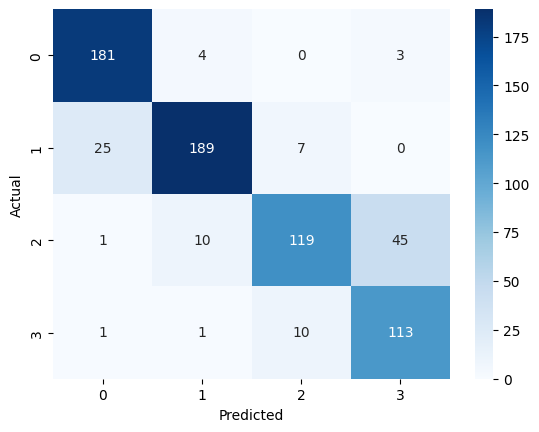

ROC-AUC: 0.8319835287114045


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

print("\nClassification Report\n")
print(classification_report(y_test, predicted))

cm = confusion_matrix(y_test, predicted)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

scores = test_spk.sum(0)

y_bin = label_binarize(y_test, classes=[0,1,2,3])

roc = roc_auc_score(y_bin, scores.numpy(), multi_class="ovr")

print("ROC-AUC:", roc)

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, predicted, average=None)
recall = recall_score(y_test, predicted, average=None)
f1 = f1_score(y_test, predicted, average=None)

labels = ["Normal", "Soap", "Mud", "Blockage"]

for i in range(4):
    print(labels[i])
    print("Precision:", precision[i])
    print("Recall:", recall[i])
    print("F1:", f1[i])
    print()

Normal
Precision: 0.8701923076923077
Recall: 0.9627659574468085
F1: 0.9141414141414141

Soap
Precision: 0.9264705882352942
Recall: 0.8552036199095022
F1: 0.8894117647058823

Mud
Precision: 0.875
Recall: 0.68
F1: 0.7652733118971061

Blockage
Precision: 0.7018633540372671
Recall: 0.904
F1: 0.7902097902097902



### Export Weights From our Trained Model

In [14]:
import numpy as np

w1 = model.fc1.weight.detach().cpu().numpy()
b1 = model.fc1.bias.detach().cpu().numpy()

w2 = model.fc2.weight.detach().cpu().numpy()
b2 = model.fc2.bias.detach().cpu().numpy()

np.save("fc1_w.npy", w1)
np.save("fc1_b.npy", b1)
np.save("fc2_w.npy", w2)
np.save("fc2_b.npy", b2)

print("Weights exported")

Weights exported


### Convert Weights → Arduino Arrays

In [15]:
import numpy as np

def to_c_array(name, arr):
    flat = arr.flatten()
    s = f"float {name}[] = {{"
    s += ",".join([str(float(x)) for x in flat])
    s += "};"
    return s

w1 = np.load("fc1_w.npy")
b1 = np.load("fc1_b.npy")
w2 = np.load("fc2_w.npy")
b2 = np.load("fc2_b.npy")

print(to_c_array("W1", w1))
print(to_c_array("B1", b1))
print(to_c_array("W2", w2))
print(to_c_array("B2", b2))

float W1[] = {-0.18438801169395447,0.18697167932987213,-0.14409001171588898,-0.5371074676513672,0.31345704197883606,-0.4543129801750183,-0.5144999623298645,-0.5304962992668152,-0.7560247182846069,-0.2569825053215027,-0.13561737537384033,-0.3413980305194855,0.4366835355758667,-1.2079559564590454,0.21843321621418,0.10411785542964935,0.13949351012706757,0.7857503294944763,-0.5180104374885559,-0.33043187856674194,0.07693228870630264,-0.5292026400566101,-0.791577935218811,-0.46436917781829834,-0.704567015171051,-0.5111594796180725,0.3632313907146454,-0.20412039756774902,-0.11011061817407608,-0.1396598070859909,-0.180378720164299,-0.2599542438983917,-2.348544120788574,-0.15308606624603271,0.3041630685329437,-2.1508750915527344,-0.2005748152732849,0.26166099309921265,-0.5382052659988403,0.06144079938530922,-0.12475105375051498,-0.9340478181838989,-1.5740736722946167,0.2802339494228363,0.9000523686408997,0.18220655620098114,-0.8443607091903687,0.6526517868041992,0.02850482426583767,0.285117357